In [11]:
import torch
import numpy as np
import cv2
import os
from tqdm import tqdm
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
from pathlib import Path
import sys
import matplotlib as plt
utils_path = r"../../../Utils"
sys.path.append(str(utils_path))
from utils import *

ROOT_DIR_CROPPED =  r"../../../../data/spark_cropped_pp_png" 
ROOT_DIR =  r"../../../../data" 
ROOT_DIR_CROPPED_SATELLITE =  r"../../../../data/spark_satellite_crop_fixed_size"

# --- UTILS PER TASK-2 ---

def get_iou(pred, gt, class_idx):
    """Calcola la Intersection over Union per una specifica classe."""
    intersection = np.logical_and(pred == class_idx, gt == class_idx).sum()
    union = np.logical_or(pred == class_idx, gt == class_idx).sum()
    if union == 0:
        return None 
    return intersection / union

def compute_success_rate(iou_list):
    """Calcola la media della percentuale di immagini sopra le soglie 0.5:0.05:0.95."""
    thresholds = np.arange(0.5, 1.0, 0.05)
    valid_ious = [iou for iou in iou_list if iou is not None]
    if not valid_ious:
        return 0.0
    
    successes = []
    for t in thresholds:
        rate = np.mean([1.0 if iou >= t else 0.0 for iou in valid_ious])
        successes.append(rate)
    return np.mean(successes)

class_map = {
    'VenusExpress': 0, 'Cheops': 1, 'LisaPathfinder': 2, 'ObservationSat1': 3,
    'Proba2': 4, 'Proba3': 5, 'Proba3ocs': 6, 'Smart1': 7, 'Soho': 8, 'XMM Newton': 9
}

In [12]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"



val_ds = PyTorchSPARKDataset(class_map=class_map, root_dir=ROOT_DIR, split='val')
val_ds_cropped  = PyTorchSPARKDataset(class_map=class_map, root_dir=ROOT_DIR_CROPPED, split='val')
val_ds_satellite_cropped  = PyTorchSPARKDataset(class_map=class_map, root_dir=ROOT_DIR_CROPPED_SATELLITE, split='val')



In [ ]:
import torch
import numpy as np
import cv2

def restore_single_image(img_tensor, bbox_expanded, original_res=(1024, 1024)):
    """
    img_tensor: Tensor [C, H, W] (es. 3, 1024, 1024)
    bbox_expanded: (x1, y1, x2, y2) coordinate originali del crop
    original_res: Risoluzione dell'immagine raw (1024, 1024)
    """
    # 1. Convert to numpy [H, W, C]
    if torch.is_tensor(img_tensor):
        if img_tensor.ndim == 4:
            img_tensor = img_tensor.squeeze(0) # Remove batch dim if present
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = img_tensor

    x1, y1, x2, y2 = bbox_expanded
    crop_w, crop_h = x2 - x1, y2 - y1

    # 2. Calculate offset (for removing black borders around the satellite)
    canvas_h, canvas_w = img_np.shape[:2] # 1024, 1024
    offset_x = (canvas_w - crop_w) // 2
    offset_y = (canvas_h - crop_h) // 2

    # 3. Extract the useful area

    useful_area = img_np[offset_y : offset_y + crop_h, offset_x : offset_x + crop_w]

    # 4. Creazione del canvas finale (Background nero)

    if useful_area.ndim == 3:
        full_res_img = np.zeros((*original_res, useful_area.shape[2]), dtype=useful_area.dtype)
    else:
        full_res_img = np.zeros(original_res, dtype=useful_area.dtype)

    # 5. Final Shift: Paste the area back to its original GT coordinates
    full_res_img[y1:y2, x1:x2] = useful_area
    
    return full_res_img
def restore_single_image_pp(img_tensor, bbox_gt, original_res=(1024, 1024)):
    """
    img_tensor: Tensor [C, 1024, 1024] (The centered crop from the dataset)
    bbox_gt: (x1, y1, x2, y2) Original Ground Truth coordinates
    original_res: Resolution of the raw image (usually 1024, 1024)
    """
    # 1. Handle Tensor to NumPy conversion
    if torch.is_tensor(img_tensor):
        if img_tensor.ndim == 4:
            img_tensor = img_tensor.squeeze(0)
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = img_tensor

    x1, y1, x2, y2 = bbox_gt
    crop_w, crop_h = x2 - x1, y2 - y1

    # 2. Calculate identical offset used during generation
    # This must use the same integer division logic // 2
    offset_x = (1024 - crop_w) // 2
    offset_y = (1024 - crop_h) // 2

    # 3. Extract the "Useful Area"
    # Slicing in NumPy is identity-preserving (no interpolation)
    useful_area = img_np[offset_y : offset_y + crop_h, offset_x : offset_x + crop_w]

    # 4. Reconstruct the original frame
    if useful_area.ndim == 3:
        full_res_img = np.zeros((*original_res, useful_area.shape[2]), dtype=useful_area.dtype)
    else:
        full_res_img = np.zeros(original_res, dtype=useful_area.dtype)

    # 5. Final Shift: Paste the area back to its original GT coordinates
    full_res_img[y1:y2, x1:x2] = useful_area
    
    return full_res_img
import torch
import numpy as np
import cv2

def restore_single_image_satellite_crop(img_tensor, bbox_gt, original_res=(1024, 1024), target_size=512):
    """

    """
    # 1. Handle Tensor to NumPy conversion
    if torch.is_tensor(img_tensor):
        if img_tensor.ndim == 4:
            img_tensor = img_tensor.squeeze(0)
        # Permute to HWC for slicing/OpenCV
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = img_tensor

    x1, y1, x2, y2 = bbox_gt
    orig_w, orig_h = x2 - x1, y2 - y1
    max_side = max(orig_w, orig_h)

    # 2. Determine Scale and Scaled Dimensions
    scale = 1.0
    if max_side > target_size:
        scale = target_size / max_side
    
    curr_w, curr_h = int(orig_w * scale), int(orig_h * scale)

    # 3. Calculate identical offset used during generation
    offset_x = (target_size - curr_w) // 2
    offset_y = (target_size - curr_h) // 2

    # 4. Extract the "Useful Area" from the 512x512 canvas
    useful_area = img_np[offset_y : offset_y + curr_h, offset_x : offset_x + curr_w]

    # 5. Reverse Scaling (if object was > 512)
    if scale != 1.0:

        useful_area = cv2.resize(useful_area, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST) #mask so we use NEAREST

    # 6. Reconstruct the original frame
    if useful_area.ndim == 3:
        full_res_frame = np.zeros((*original_res, useful_area.shape[2]), dtype=useful_area.dtype)
    else:
        full_res_frame = np.zeros(original_res, dtype=useful_area.dtype)

    # 7. Final Shift: Paste back to original coordinates
    full_res_frame[y1:y2, x1:x2] = useful_area

    return full_res_frame

In [34]:
import torch
import numpy as np
import cv2

def unshift_selective_512(model_output, bbox_gt, original_res=(1024, 1024), target_size=512):
    """
    Inverts the Selective 512 process.
    
    model_output: The 512x512 prediction (NumPy array or Tensor)
    bbox_gt: (x1, y1, x2, y2) from the CSV
    original_res: Original tile size (1024, 1024)
    """
    # 1. Standardize to NumPy HWC
    if torch.is_tensor(model_output):
        if model_output.ndim == 4: model_output = model_output.squeeze(0)
        if model_output.shape[0] < 10: # Likely [C, H, W]
            model_output = model_output.permute(1, 2, 0).cpu().numpy()
        else:
            model_output = model_output.cpu().numpy()
    
    x1, y1, x2, y2 = bbox_gt
    orig_w, orig_h = x2 - x1, y2 - y1
    max_side = max(orig_w, orig_h)
    
    # 2. MATCH THE GENERATION LOGIC
    # Case A: Fits in 512 -> No resizing, just padding
    if max_side <= target_size:
        scale = 1.0
        curr_w, curr_h = orig_w, orig_h
    # Case B: Larger than 512 -> Rescaled to fit
    else:
        scale = target_size / max_side
        curr_w, curr_h = int(orig_w * scale), int(orig_h * scale)
        
    # 3. Calculate Offsets (Must use // 2 to match shift logic)
    offset_x = (target_size - curr_w) // 2
    offset_y = (target_size - curr_h) // 2
    
    # 4. Extract the useful area (The object without the black bars)
    # We slice using the calculated scaled dimensions to avoid off-by-one errors
    useful_area = model_output[offset_y : offset_y + curr_h, offset_x : offset_x + curr_w]
    
    # 5. Handle the Rescale Back if needed
    if scale != 1.0:
        # Interpolation: INTER_NEAREST is critical for segmentation masks
        useful_area = cv2.resize(useful_area, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
    # 6. Final Shift back to original coordinates
    # Ensure the background is empty (0)
    if useful_area.ndim == 3:
        full_frame = np.zeros((*original_res, useful_area.shape[2]), dtype=useful_area.dtype)
    else:
        full_frame = np.zeros(original_res, dtype=useful_area.dtype)

    full_frame[y1:y2, x1:x2] = useful_area
    
    return full_frame

In [14]:
def check_alignment_metrics(original, reconstructed, bbox_expanded):
    x1, y1, x2, y2 = bbox_expanded
    
    # Cut the relevant crop area
    crop_orig = original[y1:y2, x1:x2]
    crop_recon = reconstructed[y1:y2, x1:x2]
    
    # Compute absolute difference
    diff = np.abs(crop_orig.astype(np.float32) - crop_recon.astype(np.float32))
    
    mae = np.mean(diff)
    max_diff = np.max(diff)
    
    return mae, max_diff

def visualize_predictions_unshifted(model, dataset, dataset_cropped, num_samples=2, device="cuda"):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1: axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            sample_cropped = dataset_cropped[idx]
            
          
            bbox = sample["bbox"].tolist()
            x_min, y_min, x_max, y_max = bbox
            dw, dh = (x_max - x_min) , (y_max - y_min) 
            x1, y1 = max(0, int(x_min - dw)), max(0, int(y_min - dh))
            x2, y2 = min(1024, int(x_max + dw)), min(1024, int(y_max + dh))
            bbox_expanded = (x1, y1, x2, y2)

            # --- Prepare Immages ---

            original_img = sample['img'].permute(1, 2, 0).cpu().numpy()
            
            # Reconstruction
            unshifted_image = restore_single_image(sample_cropped['img'], bbox_expanded, (1024, 1024))
            
            # --- Numerical Check ---
            mae, max_err = check_alignment_metrics(original_img, unshifted_image, bbox_expanded)
            
            # --- PLOT ---
            axes[i, 0].imshow(original_img)
            axes[i, 0].set_title(f"Original (Idx: {idx})")
            axes[i, 1].imshow(unshifted_image)
            axes[i, 1].set_title(f"Unshifted\nMAE: {mae:.4f}, MaxErr: {max_err:.1f}")
            
            # Heatmap of differences
            diff_img = np.abs(original_img - unshifted_image).sum(axis=-1)
            
            im = axes[i, 2].imshow(diff_img, cmap='hot')
            axes[i, 2].set_title("Difference Map")
            plt.colorbar(im, ax=axes[i, 2])

    plt.tight_layout()
    plt.show()

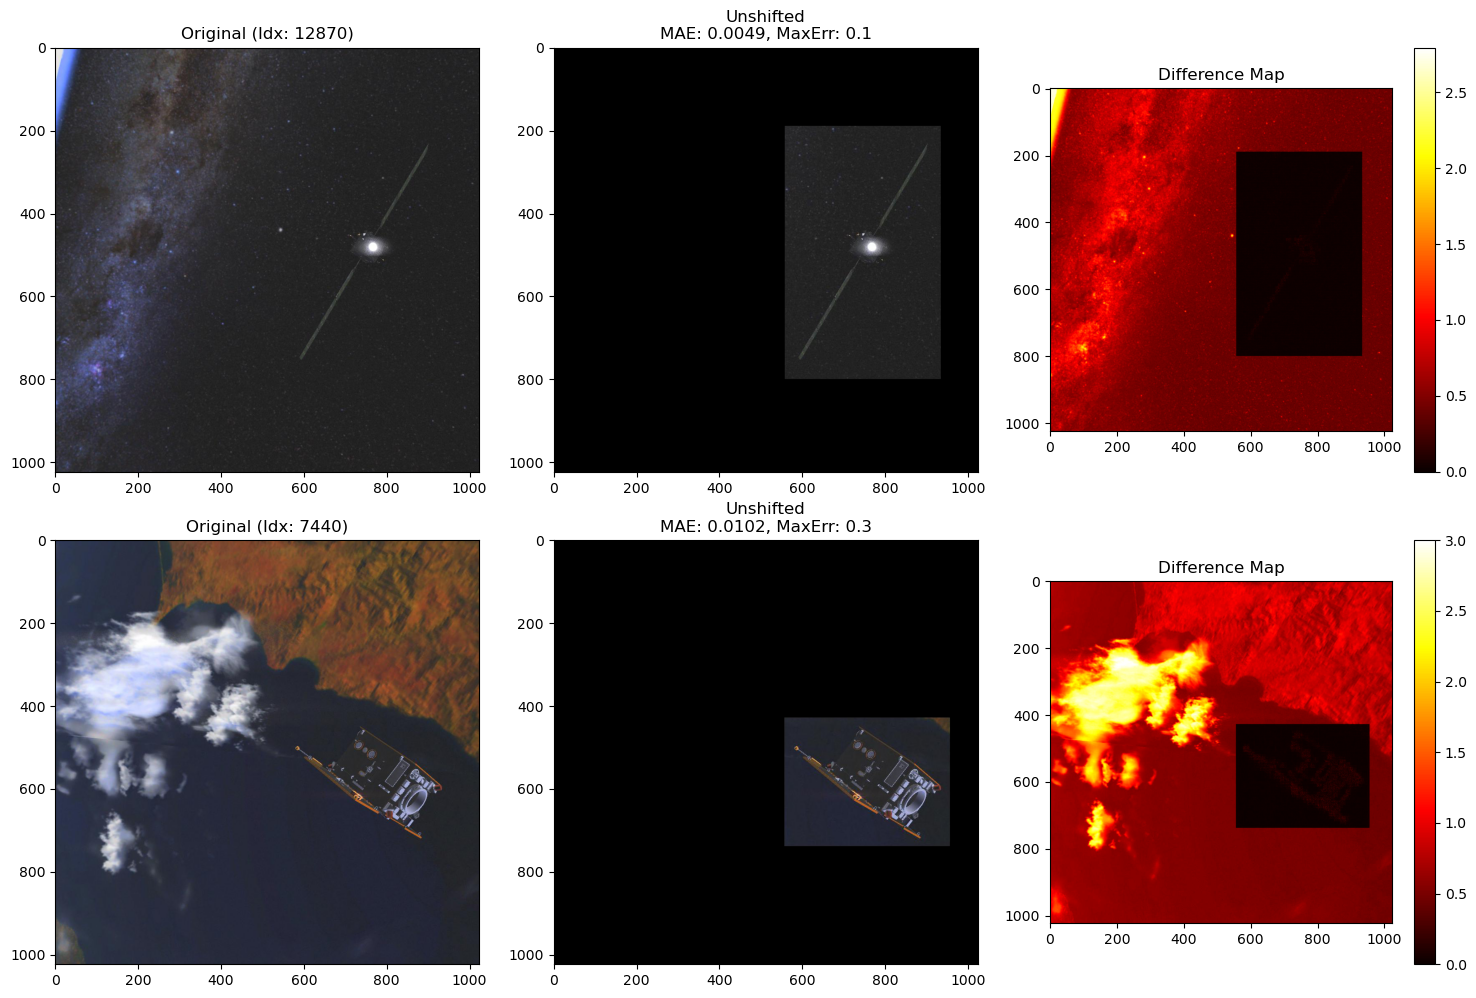

In [10]:
visualize_predictions_unshifted(None,val_ds,val_ds_cropped)

# PIXEL PERFECT WITH PNG

In [ ]:


def visualize_predictions_unshifted_pp( dataset, dataset_cropped, num_samples=2):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1: axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            sample_cropped = dataset_cropped[idx]
            
       
            bbox = sample["bbox"].tolist()
            x_min, y_min, x_max, y_max = bbox

            # --- Prepare Immages ---
    
            original_img = sample['img'].permute(1, 2, 0).cpu().numpy()
            
            # Reconstruction
            unshifted_image = restore_single_image_pp(sample_cropped['img'], bbox, (1024, 1024))
            
            # --- Numerical Check ---
            mae, max_err = check_alignment_metrics(original_img, unshifted_image, bbox)
            
            # --- PLOT ---
            axes[i, 0].imshow(original_img)
            axes[i, 0].set_title(f"Original (Idx: {idx})")
            axes[i, 1].imshow(unshifted_image)
            axes[i, 1].set_title(f"Unshifted\nMAE: {mae:.4f}, MaxErr: {max_err:.1f}")
            
            # Heatmap of differences
            diff_img = np.abs(original_img - unshifted_image).sum(axis=-1)
            #diff_img = diff_img[y_min:y_max, x_min:x_max] #uncomment to zoom on the bbox
            im = axes[i, 2].imshow(diff_img, cmap='hot')
            axes[i, 2].set_title("Difference Map")
            plt.colorbar(im, ax=axes[i, 2])

    plt.tight_layout()
    plt.show()

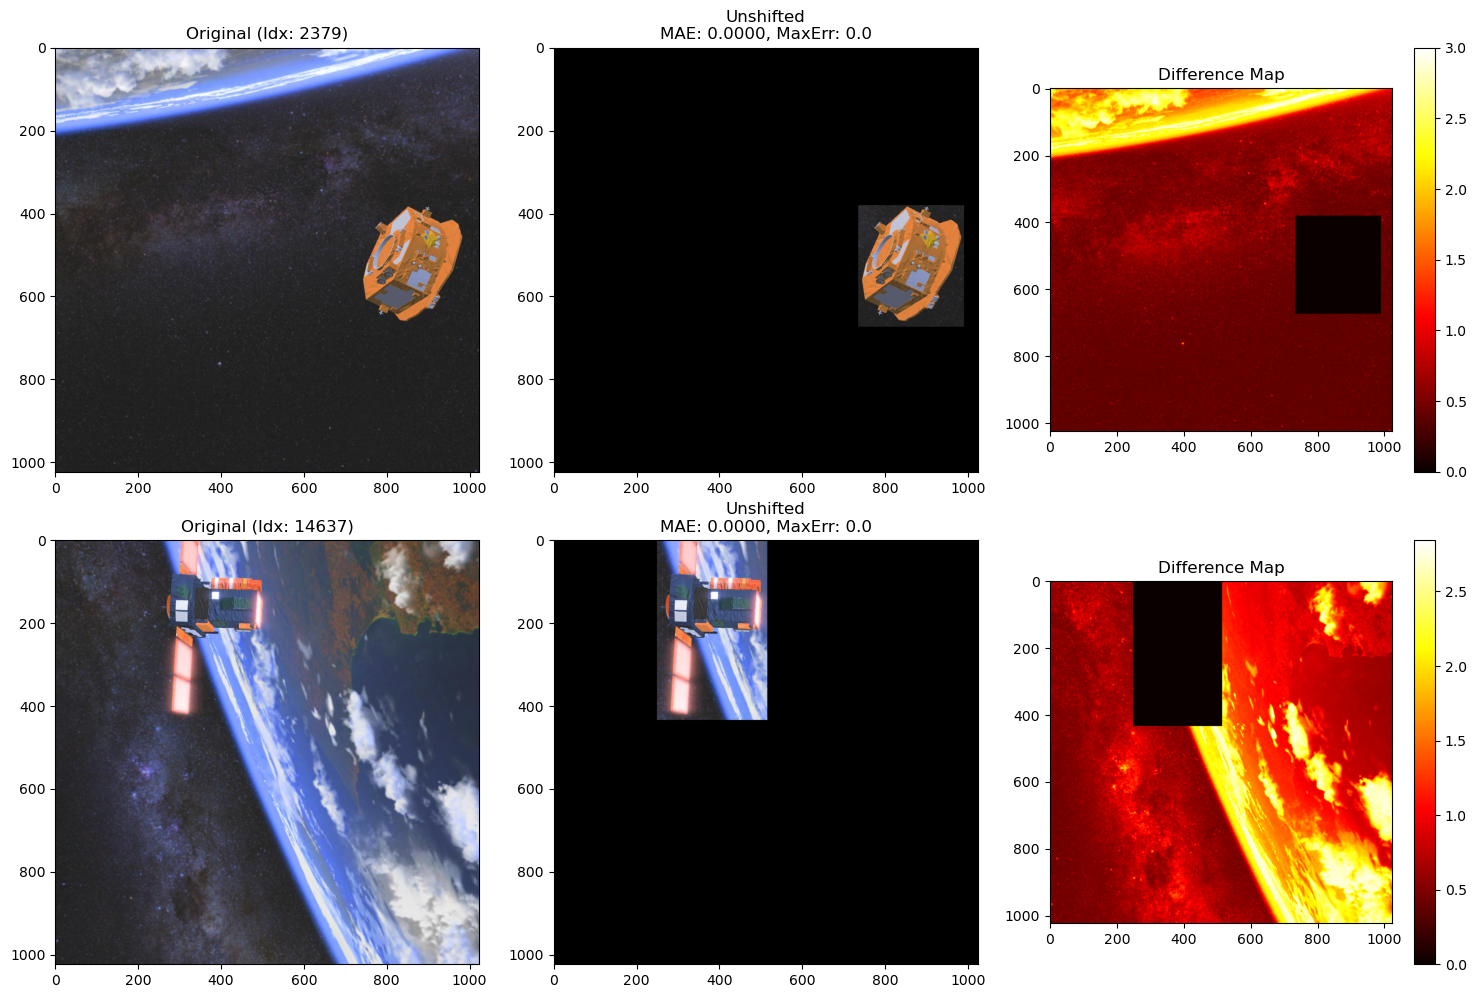

In [6]:
visualize_predictions_unshifted_pp(val_ds,val_ds_cropped)

## Satellite Crop Fixed size

In [58]:
import numpy as np
import cv2
import torch

def unshift_mirror_pil(model_output, bbox_gt, original_res=(1024, 1024), target_size=512):
    """
    RECONSTRUCTION FOR PIL-GENERATED DATASET
    Matches the exact logic of your save_centered_512_crops function.
    """
    # 1. Convert to NumPy HWC
    if torch.is_tensor(model_output):
        if model_output.ndim == 4: model_output = model_output.squeeze(0)
        # Move channels for slicing if necessary
        if model_output.shape[0] < 10: 
            model_output = model_output.permute(1, 2, 0).cpu().numpy()
        else:
            model_output = model_output.cpu().numpy()

    x1, y1, x2, y2 = bbox_gt
    orig_w, orig_h = x2 - x1, y2 - y1
    max_side = max(orig_w, orig_h)
    
    # 2. MATCH YOUR GENERATION MATH EXACTLY
    # You used: scale = target_size / max_side
    # Then: new_w, new_h = int(w * scale), int(h * scale)
    scale = 1.0
    curr_w, curr_h = orig_w, orig_h
    
    if max_side > target_size:
        scale = target_size / max_side
        curr_w = int(orig_w * scale)  # Pure int() truncation like your code
        curr_h = int(orig_h * scale)
        
    # 3. MATCH YOUR CENTERING PADS
    # You used: (target_size - curr_w) // 2
    pad_left = (target_size - curr_w) // 2
    pad_top = (target_size - curr_h) // 2
    
    # 4. SLICE THE USEFUL AREA
    # This grabs exactly the same pixels that your .paste() command placed
    useful_area = model_output[pad_top : pad_top + curr_h, pad_left : pad_left + curr_w]
    
    # 5. RESCALE BACK
    if scale != 1.0:
        # Note: Even if you used PIL to downscale, cv2.INTER_NEAREST 
        # is the most reliable way to upscale a mask back to original size.
        useful_area = cv2.resize(useful_area, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
    # 6. PASTE BACK TO TILE
    if len(useful_area.shape) == 3:
            # Create a 3D canvas: (1024, 1024, 3)
            full_frame = np.zeros((*original_res, useful_area.shape[2]), dtype=useful_area.dtype)
    else:
        # Create a 2D canvas: (1024, 1024)
        full_frame = np.zeros(original_res, dtype=useful_area.dtype)

    # 7. Perform the paste
    full_frame[y1:y2, x1:x2] = useful_area
    
    return full_frame

In [56]:


def visualize_predictions_unshifted_satellite_crop( dataset, dataset_cropped, num_samples=2):
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1: axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            sample_cropped = dataset_cropped[idx]
            
       
            bbox = sample["bbox"].tolist()
            x_min, y_min, x_max, y_max = bbox
            w, h = (x_max - x_min) , (y_max - y_min)
            
                
            # --- Prepare Immages ---
    
            original_img = sample['mask'].permute(1, 2, 0).cpu().numpy()
            
            # Reconstruction
            unshifted_image = unshift_mirror_pil(sample_cropped['mask'], bbox, (1024, 1024))
            
            # --- Numerical Check ---
            mae, max_err = check_alignment_metrics(original_img, unshifted_image, bbox)
            
            # --- PLOT ---
            axes[i, 0].imshow(original_img)
            axes[i, 0].set_title(f"Original (Idx: {idx})")
            axes[i, 1].imshow(unshifted_image)
            axes[i, 1].set_title(f"Unshifted\nMAE: {mae:.4f}, MaxErr: {max_err:.1f}")
            
            # Heatmap of differences
            diff_img = np.abs(original_img - unshifted_image).sum(axis=-1)
            diff_img = diff_img[y_min:y_max, x_min:x_max] #uncomment to zoom on the bbox
            im = axes[i, 2].imshow(diff_img, cmap='hot')
            if (w) > 512 or (h) > 512:
                axes[i, 2].set_title("Difference Map(bbox was larger than 512)")
            else:
                axes[i, 2].set_title("Difference Map")
            plt.colorbar(im, ax=axes[i, 2])

    plt.tight_layout()
    plt.show()

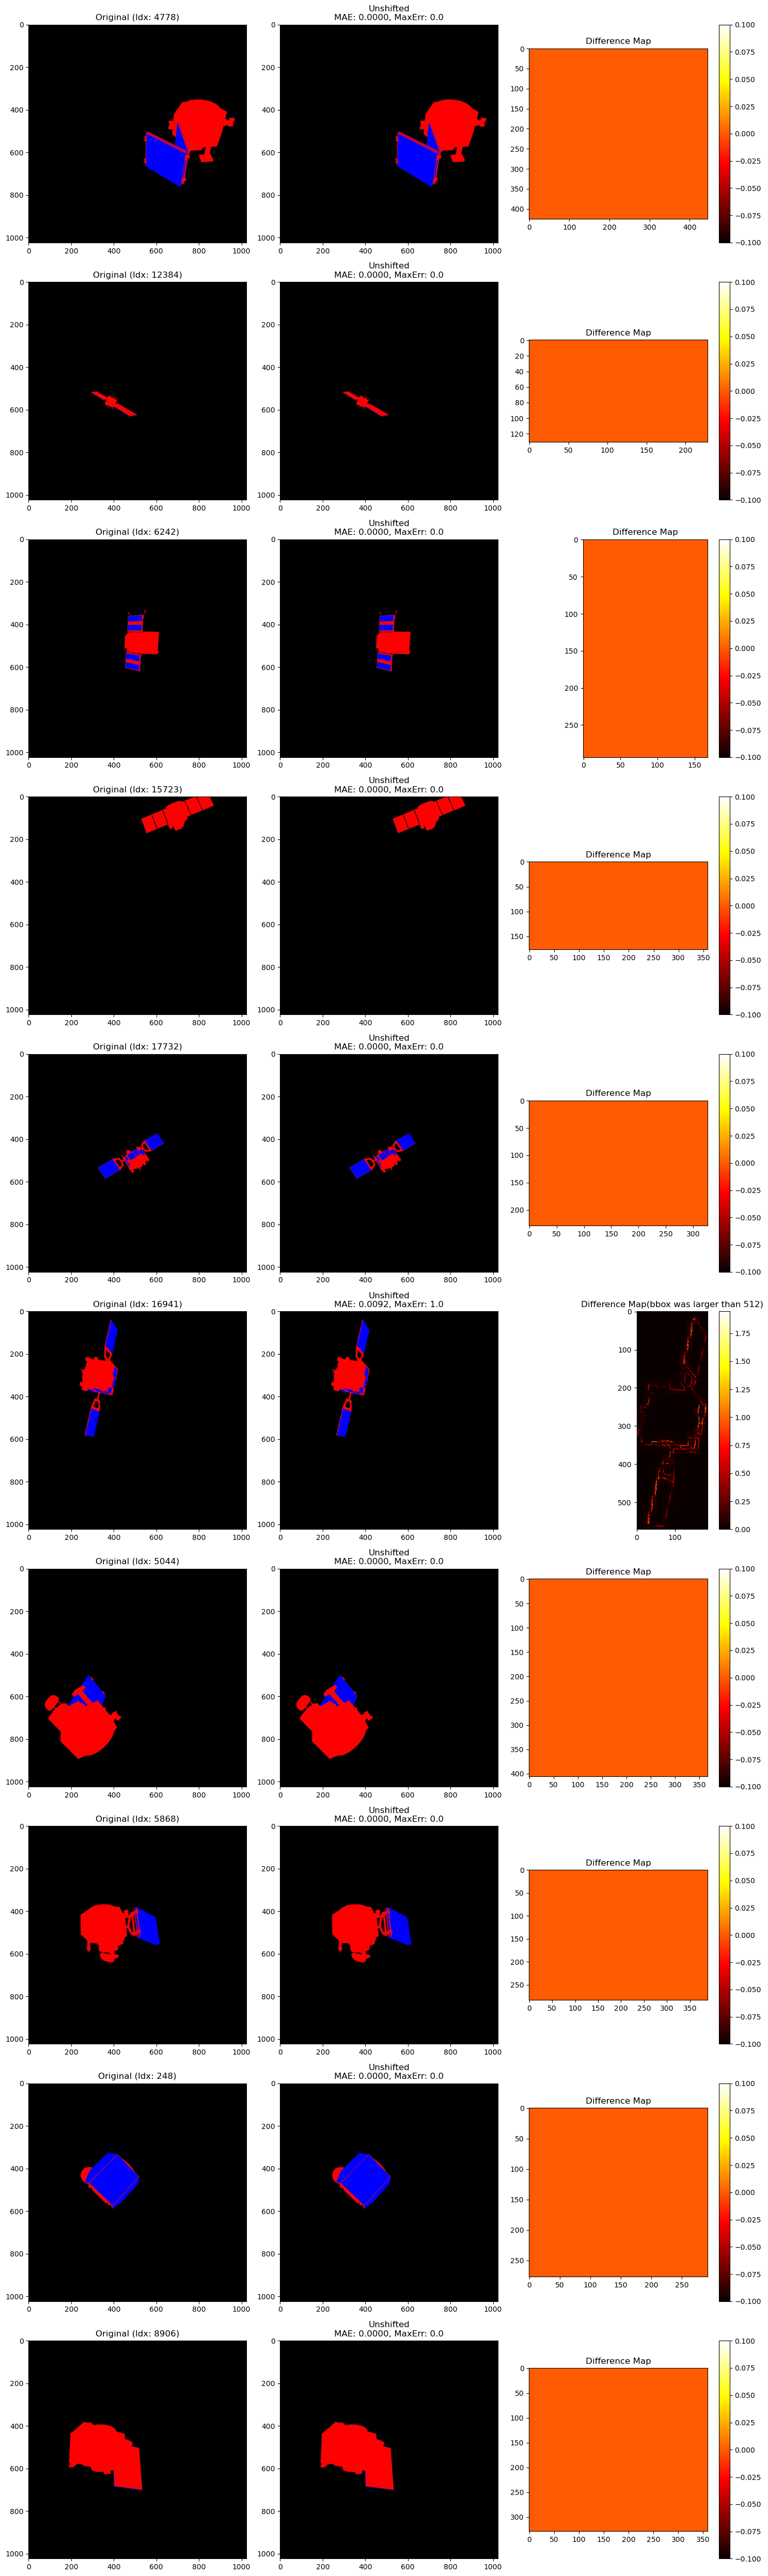

In [59]:
visualize_predictions_unshifted_satellite_crop(val_ds,val_ds_satellite_cropped,num_samples=10)